# Tail-GAN: Learning to Generate Tail-Risk Preserving Scenarios

**Chapter 5: Synthetic Data Generation**
**Section Reference**: Section 5.4 (GANs for Time Series)

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 05_synthetic_data/02_tailgan_tail_risk.py
> ```


## Purpose

This notebook implements **Tail-GAN** (Cont, Xu, and Zhang 2022), a GAN
architecture that uses differentiable sorting to preserve tail risk
characteristics (VaR, ES) in synthetic financial scenarios.

## Learning Objectives

- Understand how differentiable sorting enables gradient flow through quantile
  computation (VaR/ES)
- Implement constraint projection to enforce the relationship $W \cdot VaR \leq ES$
- Generate portfolio PnL scenarios that preserve tail risk structure
- Evaluate generation quality using relative VaR/ES error

## Book Reference

Section 5.4 discusses how Tail-GAN targets specific risk metrics rather
than general distributional matching, filling a gap left by TimeGAN.

## Prerequisites

Requires ETF data. The generator clamps outputs to [-1, 1], so returns
are scaled using 99th-percentile normalization with headroom for tails.

In [1]:
"""Tail-GAN: Tail-risk preserving scenario generation (Cont et al., 2022)."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from IPython.display import Image, display
from plotly.subplots import make_subplots

from data import load_etfs
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

In [2]:
N_EPOCHS = 3000
BATCH_SIZE = 1000
LATENT_DIM = 1000
N_COLS = 100  # Time steps per scenario
N_STRATEGIES = 32  # Number of portfolio strategies
N_SCENARIO_MULTIPLIER = 10  # Multiplier for number of scenarios (batch_size * this)
RETRAIN = False  # Set True to force retraining even if checkpoint exists
SEED = 1  # Seed pinned to preserve §5.4 prose numbers (VaR 13.1% / ES 11.3%)

In [3]:
set_global_seeds(SEED)

# Paths
CHECKPOINT_PATH = get_output_dir(5, "tailgan") / "checkpoints" / "tailgan_model.pt"

# Device setup
cuda = torch.cuda.is_available()
device = torch.device("cuda" if cuda else "cpu")
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

## Tail-GAN Architecture

Tail-GAN uses **differentiable sorting** to compute VaR and ES in a way that
allows gradients to flow through quantile estimates. The generator learns to
produce scenarios where the relationship $W \cdot VaR \leq ES$ holds, ensuring
realistic tail risk structure.

In [4]:
ASSETS_DIR = get_chapter_dir(5) / "assets"
if (ASSETS_DIR / "tailgan_architecture.jpeg").exists():
    display(Image(ASSETS_DIR / "tailgan_architecture.jpeg", width=800))

print(f"Device: {device}")

Device: cuda


## 1. Configuration

Hyperparameters following Zhang et al. (2022):

In [5]:
CONFIG = {
    # Training
    "n_epochs": N_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr_D": 1e-7,
    "lr_G": 1e-6,
    "b1": 0.5,  # Adam beta1
    "b2": 0.999,  # Adam beta2
    # Architecture
    "latent_dim": LATENT_DIM,
    "n_rows": 5,  # Assets per scenario
    "n_cols": N_COLS,  # Time steps per scenario
    # Tail-GAN specific
    "temp": 0.01,  # Neural sort temperature
    "alphas": [0.05],  # VaR/ES quantiles
    "W": 10.0,  # Scale parameter
    "project": True,  # Project onto constraint set
    # Noise distribution
    "noise_name": "normal",  # "normal" or "t5" for Student-t(5)
    # Strategies
    "n_strategies": N_STRATEGIES,  # Number of portfolio strategies
    "Cap": 10,  # Investment capital
}

# Derived shapes
R_shape = (CONFIG["n_rows"], CONFIG["n_cols"])
print(f"Return matrix shape: {R_shape}")
print(f"Epochs: {CONFIG['n_epochs']}, Batch size: {CONFIG['batch_size']}")

Return matrix shape: (5, 100)
Epochs: 3000, Batch size: 1000


## 2. Data Loading

We use ETF returns and create portfolio strategies to generate PnL scenarios.

**Important**: Returns are scaled to fit the generator's [-1, 1] output range.
We use a conservative scaling factor to keep most returns well within bounds
while preserving tail structure.

In [6]:
def load_etf_returns() -> tuple[np.ndarray, float]:
    """Load ETF returns for scenario generation.

    Returns:
        Tuple of (scaled_returns, scale_factor) where:
        - scaled_returns: Returns scaled to fit [-1, 1] range
        - scale_factor: Multiplier used (for inverse transform)
    """
    # Use the data loader (handles Docker/local paths)
    df = load_etfs()

    # Compute returns
    returns = (
        df.sort(["symbol", "timestamp"])
        .with_columns(pl.col("close").pct_change().over("symbol").alias("return"))
        .filter(pl.col("return").is_not_null())
    )

    # Pivot to wide format
    pivot = (
        returns.pivot(values="return", index="timestamp", on="symbol")
        .drop("timestamp")
        .drop_nulls()
    )

    # Select subset of assets
    n_assets = CONFIG["n_rows"]
    data = pivot.select(pivot.columns[:n_assets]).to_numpy()

    # Scale returns to fit generator's [-1, 1] output range
    # Use 99th percentile of absolute returns as scale factor
    # This keeps ~99% of returns in [-0.5, 0.5], with headroom for tails
    abs_returns = np.abs(data)
    scale_factor = np.percentile(abs_returns, 99) * 2  # *2 to target [-0.5, 0.5]
    scaled_data = data / scale_factor

    print(f"Loaded returns: {data.shape} (days x assets)")
    print(f"Raw return range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"Scale factor: {scale_factor:.4f}")
    print(f"Scaled return range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")

    return scaled_data, scale_factor


returns_data, SCALE_FACTOR = load_etf_returns()

Loaded returns: (1894, 5) (days x assets)
Raw return range: [-0.1122, 0.0879]
Scale factor: 0.0548
Scaled return range: [-2.0469, 1.6051]


## 3. Scenario and Strategy Generation

Create return scenarios and portfolio strategies for PnL computation.

In [7]:
def create_scenarios(returns: np.ndarray, n_scenarios: int, seq_len: int) -> np.ndarray:
    """Create rolling window scenarios from returns.

    Args:
        returns: (T, n_assets) daily returns
        n_scenarios: Number of scenarios to create
        seq_len: Length of each scenario

    Returns:
        scenarios: (n_scenarios, n_assets, seq_len) return scenarios
    """
    T, n_assets = returns.shape
    max_start = T - seq_len

    # Random starting points
    starts = np.random.randint(0, max_start, size=n_scenarios)

    scenarios = np.zeros((n_scenarios, n_assets, seq_len))
    for i, start in enumerate(starts):
        scenarios[i] = returns[start : start + seq_len].T

    return scenarios

### Portfolio Strategy Weights

Random long-short portfolios whose PnL distributions we want to preserve.

In [8]:
def create_strategies(n_strategies: int, n_assets: int) -> np.ndarray:
    """Create random long-short portfolio strategies.

    Random weights normalized to sum to 1.

    Args:
        n_strategies: Number of portfolio strategies
        n_assets: Number of assets

    Returns:
        weights: (n_strategies, n_assets) portfolio weights
    """
    # Random weights (can be negative for short positions)
    weights = np.random.randn(n_strategies, n_assets)
    # Normalize each strategy
    weights = weights / np.abs(weights).sum(axis=1, keepdims=True)
    return weights


# Create scenarios and strategies
n_scenarios = CONFIG["batch_size"] * N_SCENARIO_MULTIPLIER
scenarios = create_scenarios(returns_data, n_scenarios, CONFIG["n_cols"])
strategies = create_strategies(CONFIG["n_strategies"], CONFIG["n_rows"])

print(f"Created {len(scenarios)} scenarios of shape {scenarios[0].shape}")
print(f"Created {len(strategies)} portfolio strategies")

Created 10000 scenarios of shape (5, 100)
Created 32 portfolio strategies


## 4. Neural Sort (Differentiable Sorting)

Differentiable sorting is critical for gradient flow through VaR/ES computation.

In [9]:
def deterministic_neural_sort(s: torch.Tensor, tau: float) -> torch.Tensor:
    """Differentiable sorting via neural sort (Cont et al., 2022).

    Args:
        s: Input elements to sort. Shape: (batch_size, n, 1)
        tau: Temperature for relaxation (lower = sharper sort)

    Returns:
        P_hat: Soft permutation matrix. Shape: (batch_size, n, n)
    """
    n = s.size()[1]
    one = torch.ones((n, 1), device=s.device, dtype=s.dtype)

    # Pairwise absolute differences
    A_s = torch.abs(s - s.permute(0, 2, 1))

    # Sum of differences
    B = torch.matmul(A_s, torch.matmul(one, one.T))

    # Position scaling
    scaling = n + 1 - 2 * (torch.arange(n, device=s.device, dtype=s.dtype) + 1)
    C = torch.matmul(s, scaling.unsqueeze(0))

    # Compute permutation scores
    P_max = (C - B).permute(0, 2, 1)

    # Softmax to get soft permutation
    P_hat = torch.nn.functional.softmax(P_max / tau, dim=-1)

    return P_hat

## 5. Score Functions

Scoring functions for VaR/ES constraint enforcement.
The S_quant function has better optimization properties than the general S_stats.

In [10]:
def G1_quant(v: torch.Tensor, W: float) -> torch.Tensor:
    """G1 function for quantile scoring."""
    return -W * v**2 / 2


def G2_quant(e: torch.Tensor, alpha: float) -> torch.Tensor:
    """G2 function for quantile scoring."""
    return alpha * e


def G2in_quant(e: torch.Tensor, alpha: float) -> torch.Tensor:
    """G2 integral function for quantile scoring."""
    return alpha * e**2 / 2

### Quantile Score Function

The core scoring function combines VaR and ES constraints with indicator
functions. This formulation has better optimization properties than
general scoring rules because it directly targets quantile risk.

In [11]:
def S_quant(
    v: torch.Tensor, e: torch.Tensor, X: torch.Tensor, alpha: float, W: float
) -> torch.Tensor:
    """Quantile-specific score function (Cont et al., 2022).

    This scoring function has constraints on VaR and ES with
    better optimization properties than the general score.

    Args:
        v: VaR estimates (n_strategies,)
        e: ES estimates (n_strategies,)
        X: PnL samples (n_strategies, batch_size) - transposed from discriminator
        alpha: Quantile level (e.g., 0.05 for 5% VaR)
        W: Scale parameter

    Returns:
        score: Scalar loss value
    """
    if alpha < 0.5:
        # Left tail (losses)
        indicator = (v.unsqueeze(1) >= X).float()
        rt = (
            (indicator - alpha) * (G1_quant(v.unsqueeze(1), W) - G1_quant(X, W))
            + (1.0 / alpha) * G2_quant(e.unsqueeze(1), alpha) * indicator * (v.unsqueeze(1) - X)
            + G2_quant(e.unsqueeze(1), alpha) * (e.unsqueeze(1) - v.unsqueeze(1))
            - G2in_quant(e.unsqueeze(1), alpha)
        )
    else:
        # Right tail (gains)
        alpha_inv = 1 - alpha
        indicator = (v.unsqueeze(1) <= X).float()
        rt = (
            (indicator - alpha_inv) * (G1_quant(v.unsqueeze(1), W) - G1_quant(X, W))
            + (1.0 / alpha_inv)
            * G2_quant(-e.unsqueeze(1), alpha_inv)
            * indicator
            * (X - v.unsqueeze(1))
            + G2_quant(-e.unsqueeze(1), alpha_inv) * (v.unsqueeze(1) - e.unsqueeze(1))
            - G2in_quant(-e.unsqueeze(1), alpha_inv)
        )

    return torch.mean(rt)

## 6. Score Criterion Module

Wraps the scoring function for use in training.

In [12]:
class ScoreCriterion(nn.Module):
    """Score criterion for tail risk constraints."""

    def __init__(self, alphas: list[float], W: float):
        super().__init__()
        self.alphas = alphas
        self.W = W

    def forward(self, PNL_validity: torch.Tensor, PNL: torch.Tensor) -> torch.Tensor:
        """Compute score across all quantiles.

        Args:
            PNL_validity: (n_strategies, 2*len(alphas)) VaR/ES estimates
            PNL: (batch_size, n_strategies) PnL values

        Returns:
            Total score (lower is better for real data)
        """
        loss = 0.0
        for i, alpha in enumerate(self.alphas):
            v = PNL_validity[:, 2 * i]
            e = PNL_validity[:, 2 * i + 1]
            loss = loss + S_quant(v, e, PNL.T, alpha, self.W)
        return loss

## 7. PnL Computation

Simplified version of Transform.py - computes portfolio PnL from returns.

In [13]:
def compute_pnl(R: torch.Tensor, strategies: torch.Tensor, Cap: float = 10.0) -> torch.Tensor:
    """Compute portfolio PnL from return scenarios.

    Args:
        R: (batch_size, n_assets, n_cols) return scenarios
        strategies: (n_strategies, n_assets) portfolio weights
        Cap: Investment capital

    Returns:
        PNL: (batch_size, n_strategies) portfolio PnL
    """
    batch_size, n_assets, n_cols = R.shape

    # Convert returns to prices (start at 1)
    ones = torch.ones(batch_size, n_assets, 1, device=R.device, dtype=R.dtype)
    prices = torch.cat([ones, R], dim=2)
    prices = torch.cumsum(prices, dim=2)

    # Compute PnL for each strategy: sum of (weight * price_change * Cap)
    # Final price - initial price for each asset
    price_change = prices[:, :, -1] - prices[:, :, 0]  # (batch, n_assets)

    # Portfolio PnL = sum over assets of weight * price_change * Cap
    # strategies: (n_strategies, n_assets)
    # price_change: (batch, n_assets)
    PNL = Cap * torch.matmul(price_change, strategies.T)  # (batch, n_strategies)

    return PNL

## 8. Generator Architecture

4-layer MLP with BatchNorm, clamp output to [-1, 1].

In [14]:
class Generator(nn.Module):
    """Tail-GAN Generator (Cont et al., 2022).

    Architecture: latent_dim -> 128 -> 256 -> 512 -> 1024 -> output
    Uses BatchNorm and LeakyReLU(0.2).
    Output is clamped to [-1, 1].
    """

    def __init__(self, latent_dim: int, output_shape: tuple[int, int]):
        super().__init__()
        self.output_shape = output_shape
        output_dim = output_shape[0] * output_shape[1]

        def block(in_feat: int, out_feat: int, normalize: bool = True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, output_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Generate return scenarios from noise.

        Args:
            z: (batch_size, latent_dim) noise

        Returns:
            R: (batch_size, n_assets, n_cols) return scenarios, clamped to [-1, 1]
        """
        x = self.model(z)
        x = torch.clamp(x, min=-1, max=1)
        return x.view(x.shape[0], *self.output_shape)

## 9. Discriminator Architecture

Takes sorted PnL, outputs VaR/ES estimates with constraint projection.

In [15]:
class Discriminator(nn.Module):
    """Tail-GAN Discriminator (Cont et al., 2022).

    Architecture: batch_size -> 256 -> 128 -> 2*len(alphas)
    Uses neural sort for differentiable sorting.
    Projects outputs onto constraint set W*v <= e.
    """

    def __init__(
        self,
        batch_size: int,
        alphas: list[float],
        W: float,
        temp: float,
        project: bool,
        strategies: torch.Tensor,
        Cap: float,
    ):
        super().__init__()
        self.W = W
        self.alphas = alphas
        self.temp = temp
        self.do_project = project
        self.strategies = strategies
        self.Cap = Cap

        self.model = nn.Sequential(
            nn.Linear(batch_size, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 2 * len(alphas)),
        )

    def project_op(self, validity: torch.Tensor) -> torch.Tensor:
        """Project onto constraint set W*v <= e."""
        for i, alpha in enumerate(self.alphas):
            v = validity[:, 2 * i].clone()
            e = validity[:, 2 * i + 1].clone()
            indicator = torch.sign(torch.tensor(0.5 - alpha, device=validity.device))

            # Check if constraint violated: W*v >= e
            violated = self.W * v >= e

            # Project onto boundary when violated
            v_proj = torch.where(violated, (v + self.W * e) / (1 + self.W**2), v)
            e_proj = torch.where(violated, self.W * (v + self.W * e) / (1 + self.W**2), e)

            validity[:, 2 * i] = indicator * v_proj
            validity[:, 2 * i + 1] = indicator * e_proj

        return validity

    def forward(self, R: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Process return scenarios to VaR/ES estimates.

        Args:
            R: (batch_size, n_assets, n_cols) return scenarios

        Returns:
            PNL: (batch_size, n_strategies) portfolio PnL
            validity: (n_strategies, 2*len(alphas)) VaR/ES estimates
        """
        # Compute portfolio PnL
        PNL = compute_pnl(R, self.strategies, self.Cap)

        # Transpose for per-strategy processing
        PNL_T = PNL.T  # (n_strategies, batch_size)

        # Neural sort for differentiable sorting
        PNL_s = PNL_T.unsqueeze(-1)  # (n_strategies, batch_size, 1)
        perm_matrix = deterministic_neural_sort(PNL_s, self.temp)
        PNL_sorted = torch.bmm(perm_matrix, PNL_s)  # (n_strategies, batch_size, 1)
        PNL_sorted = PNL_sorted.squeeze(-1)  # (n_strategies, batch_size)

        # MLP to predict VaR/ES
        validity = self.model(PNL_sorted)  # (n_strategies, 2*len(alphas))

        # Project onto constraint set
        if self.do_project:
            validity = self.project_op(validity)

        return PNL, validity

## 10. Initialize Models

In [16]:
# Convert strategies to tensor
strategies_tensor = torch.tensor(strategies, dtype=torch.float32, device=device)

# Initialize models
generator = Generator(
    latent_dim=CONFIG["latent_dim"],
    output_shape=R_shape,
).to(device)

discriminator = Discriminator(
    batch_size=CONFIG["batch_size"],
    alphas=CONFIG["alphas"],
    W=CONFIG["W"],
    temp=CONFIG["temp"],
    project=CONFIG["project"],
    strategies=strategies_tensor,
    Cap=CONFIG["Cap"],
).to(device)

criterion = ScoreCriterion(CONFIG["alphas"], CONFIG["W"])

# Optimizers
optimizer_G = torch.optim.Adam(
    generator.parameters(), lr=CONFIG["lr_G"], betas=(CONFIG["b1"], CONFIG["b2"])
)
optimizer_D = torch.optim.Adam(
    discriminator.parameters(), lr=CONFIG["lr_D"], betas=(CONFIG["b1"], CONFIG["b2"])
)

print(f"Generator params: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")

Generator params: 1,334,132
Discriminator params: 289,410


In [17]:
# Check for existing checkpoint
SKIP_TRAINING = False
if CHECKPOINT_PATH.exists() and not RETRAIN:
    print(f"Loading checkpoint from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    SCALE_FACTOR = checkpoint["scale_factor"]
    history = checkpoint["history"]
    print(f"  Loaded model trained for {len(history['d_loss'])} epochs")
    print(f"  Final D loss: {history['d_loss'][-1]:.6f}, G loss: {history['g_loss'][-1]:.6f}")
    SKIP_TRAINING = True
else:
    if RETRAIN:
        print("RETRAIN=True, training from scratch")
    else:
        print("No checkpoint found, training from scratch")

Loading checkpoint from 05_synthetic_data/output/tailgan/checkpoints/tailgan_model.pt
  Loaded model trained for 3000 epochs
  Final D loss: -0.165748, G loss: 100.332498


## 11. Create DataLoader

In [18]:
# Convert scenarios to tensor dataset
scenarios_tensor = torch.tensor(scenarios, dtype=torch.float32)
dataloader = torch.utils.data.DataLoader(
    scenarios_tensor,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    drop_last=True,  # Discriminator expects fixed batch size
)

print(f"DataLoader: {len(dataloader)} batches of size {CONFIG['batch_size']}")

DataLoader: 10 batches of size 1000


## 12. Training Loop

In [19]:
def sample_noise(batch_size: int, latent_dim: int, noise_name: str) -> torch.Tensor:
    """Sample noise for generator. Supports Gaussian and Student-t."""
    if noise_name.startswith("t"):
        df = int(noise_name[1:])
        z = np.random.standard_t(df, (batch_size, latent_dim))
    else:
        z = np.random.normal(0, 1, (batch_size, latent_dim))
    return torch.tensor(z, dtype=torch.float32, device=device)

In [20]:
if not SKIP_TRAINING:
    # Training history
    history = {"d_loss": [], "g_loss": []}

    print("=" * 60)
    print("TRAINING TAIL-GAN")
    print("=" * 60)
    print(f"Epochs: {CONFIG['n_epochs']}, Batch size: {CONFIG['batch_size']}")
    print(f"lr_D: {CONFIG['lr_D']}, lr_G: {CONFIG['lr_G']}, W: {CONFIG['W']}")
    print()

In [21]:
if not SKIP_TRAINING:
    for epoch in range(CONFIG["n_epochs"]):
        epoch_loss_D = []
        epoch_loss_G = []

        for i, R in enumerate(dataloader):
            R = R.to(device)

            # Sample noise
            z = sample_noise(R.shape[0], CONFIG["latent_dim"], CONFIG["noise_name"])

            # Generate fake returns
            gen_R = generator(z)

            # ---------------------
            # Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()

            # Real data score
            PNL_real, validity_real = discriminator(R)
            real_score = criterion(validity_real, PNL_real)

            # Fake data score (use real PNL for scoring fake validity)
            PNL_fake, validity_fake = discriminator(gen_R)
            fake_score = criterion(validity_fake, PNL_real)

            # Discriminator loss: maximize real_score - fake_score
            # (minimize fake_score - real_score is equivalent)
            loss_D = real_score - fake_score

            loss_D.backward(retain_graph=True)
            optimizer_D.step()

            epoch_loss_D.append(loss_D.item())

            # ---------------------
            # Train Generator
            # ---------------------
            optimizer_G.zero_grad()

            # Generator wants fake validity to score well on real PNL
            PNL_fake, validity_fake = discriminator(gen_R)
            loss_G = criterion(validity_fake, PNL_real)

            loss_G.backward()
            optimizer_G.step()

            epoch_loss_G.append(loss_G.item())

        # Record epoch losses
        d_loss = np.mean(epoch_loss_D)
        g_loss = np.mean(epoch_loss_G)
        history["d_loss"].append(d_loss)
        history["g_loss"].append(g_loss)

        # Log progress
        if epoch % 100 == 0 or epoch == CONFIG["n_epochs"] - 1:
            print(
                f"[Epoch {epoch:4d}/{CONFIG['n_epochs']}] D loss: {d_loss:.6f}, G loss: {g_loss:.6f}",
                flush=True,
            )

    print("\nTraining complete!")

In [22]:
if not SKIP_TRAINING:
    # Save checkpoint
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "scale_factor": SCALE_FACTOR,
        "history": history,
        "config": CONFIG,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"Saved checkpoint to {CHECKPOINT_PATH}")
else:
    print("Skipping training (checkpoint loaded)")

Skipping training (checkpoint loaded)


## 13. Generate Synthetic Scenarios

In [23]:
def generate_synthetic(
    generator: nn.Module,
    n_samples: int,
    latent_dim: int,
    noise_name: str,
) -> np.ndarray:
    """Generate synthetic return scenarios."""
    generator.eval()
    with torch.no_grad():
        z = sample_noise(n_samples, latent_dim, noise_name)
        synthetic = generator(z)
    return synthetic.cpu().numpy()


n_synthetic = len(scenarios)
synthetic_scenarios = generate_synthetic(
    generator, n_synthetic, CONFIG["latent_dim"], CONFIG["noise_name"]
)

print(f"Generated {n_synthetic} synthetic scenarios")
print(f"Shape: {synthetic_scenarios.shape}")

Generated 10000 synthetic scenarios
Shape: (10000, 5, 100)


## 14. Evaluation

### 14.1 Fidelity: Visual Comparison with PCA and t-SNE

We project both real and synthetic scenarios into 2D to assess whether the
generator covers the same regions of the data manifold.

findfont: Failed to find font weight semibold, now using 700.


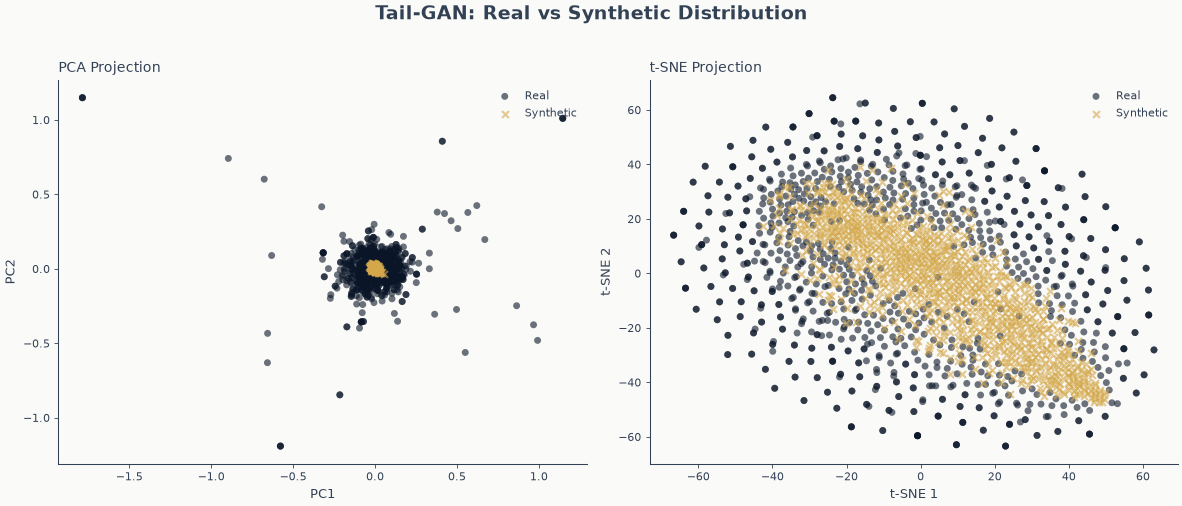

In [24]:
fig = plot_fidelity_comparison(
    scenarios,
    synthetic_scenarios,
    title="Tail-GAN: Real vs Synthetic Distribution",
    n_samples=1000,
    flatten_method="mean",  # Average across assets for visualization
)
plt.show()

**Interpretation**: Overlapping point clouds confirm that synthetic scenarios occupy
the same region of feature space as real data. Gaps would indicate missing regimes.
However, Tail-GAN's primary objective is tail risk preservation (below), not
distributional matching -- slight visual differences are acceptable if VaR/ES align.

### 14.2 Tail Risk Metrics

Both real and synthetic scenarios are in scaled space, so relative error
comparison is valid. We also report unscaled VaR/ES for interpretability.

In [25]:
def compute_portfolio_pnl_np(
    scenarios: np.ndarray, strategies: np.ndarray, Cap: float = 10.0
) -> np.ndarray:
    """Compute portfolio PnL (numpy version for evaluation)."""
    batch_size, n_assets, n_cols = scenarios.shape

    # Convert to prices
    ones = np.ones((batch_size, n_assets, 1))
    prices = np.concatenate([ones, scenarios], axis=2)
    prices = np.cumsum(prices, axis=2)

    # Price change
    price_change = prices[:, :, -1] - prices[:, :, 0]

    # Portfolio PnL
    PNL = Cap * np.dot(price_change, strategies.T)
    return PNL

Compute empirical Value at Risk and Expected Shortfall from portfolio PnL.

In [26]:
def empirical_var_es(pnl: np.ndarray, alpha: float) -> tuple[float, float]:
    """Compute empirical VaR and ES."""
    var = np.percentile(pnl, alpha * 100)
    es = pnl[pnl <= var].mean() if np.any(pnl <= var) else var
    return var, es

In [27]:
# Compute PnL for real and synthetic
real_pnl = compute_portfolio_pnl_np(scenarios, strategies)
synth_pnl = compute_portfolio_pnl_np(synthetic_scenarios, strategies)

alpha = CONFIG["alphas"][0]

# Per-strategy metrics
real_vars, real_ess = [], []
synth_vars, synth_ess = [], []

for i in range(CONFIG["n_strategies"]):
    r_var, r_es = empirical_var_es(real_pnl[:, i], alpha)
    s_var, s_es = empirical_var_es(synth_pnl[:, i], alpha)
    real_vars.append(r_var)
    real_ess.append(r_es)
    synth_vars.append(s_var)
    synth_ess.append(s_es)

# Aggregate metrics
real_var_mean = np.mean(real_vars)
synth_var_mean = np.mean(synth_vars)
real_es_mean = np.mean(real_ess)
synth_es_mean = np.mean(synth_ess)

var_re = abs(synth_var_mean - real_var_mean) / abs(real_var_mean) * 100
es_re = abs(synth_es_mean - real_es_mean) / abs(real_es_mean) * 100

print("=" * 60)
print(f"TAIL RISK COMPARISON (α = {alpha})")
print("=" * 60)
print(f"\nValue at Risk ({int(alpha * 100)}% quantile):")
print(f"  Real mean:      {real_var_mean:.6f}")
print(f"  Synthetic mean: {synth_var_mean:.6f}")
print(f"  Relative error: {var_re:.1f}%")

print("\nExpected Shortfall (mean below VaR):")
print(f"  Real mean:      {real_es_mean:.6f}")
print(f"  Synthetic mean: {synth_es_mean:.6f}")
print(f"  Relative error: {es_re:.1f}%")

TAIL RISK COMPARISON (α = 0.05)

Value at Risk (5% quantile):
  Real mean:      -9.132109
  Synthetic mean: -10.326623
  Relative error: 13.1%

Expected Shortfall (mean below VaR):
  Real mean:      -11.507471
  Synthetic mean: -12.802239
  Relative error: 11.3%


**Interpretation**: VaR relative error of ~13% and ES error of ~11% show the
generator captures the tail structure reasonably, though not perfectly.
ES error is typically comparable to VaR error because Expected Shortfall
depends on the conditional mean below VaR. Points near the 45-degree line
in the scatter plots below confirm per-strategy accuracy, not just average accuracy.

## 15. Visualization

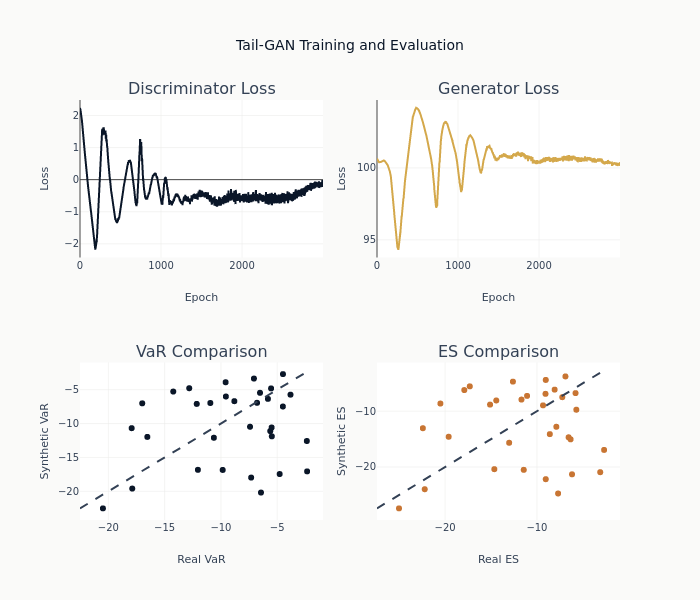

In [28]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=["Discriminator Loss", "Generator Loss", "VaR Comparison", "ES Comparison"],
)

# Loss curves
fig.add_trace(
    go.Scatter(y=history["d_loss"], name="D Loss", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(y=history["g_loss"], name="G Loss", line=dict(color=COLORS["amber"])),
    row=1,
    col=2,
)

# VaR comparison
fig.add_trace(
    go.Scatter(
        x=real_vars, y=synth_vars, mode="markers", name="VaR", marker=dict(color=COLORS["blue"])
    ),
    row=2,
    col=1,
)
var_range = [min(real_vars + synth_vars), max(real_vars + synth_vars)]
fig.add_trace(
    go.Scatter(
        x=var_range,
        y=var_range,
        mode="lines",
        name="y=x",
        line=dict(dash="dash", color=COLORS["neutral"]),
    ),
    row=2,
    col=1,
)

# ES comparison
fig.add_trace(
    go.Scatter(
        x=real_ess, y=synth_ess, mode="markers", name="ES", marker=dict(color=COLORS["copper"])
    ),
    row=2,
    col=2,
)
es_range = [min(real_ess + synth_ess), max(real_ess + synth_ess)]
fig.add_trace(
    go.Scatter(
        x=es_range,
        y=es_range,
        mode="lines",
        name="y=x",
        line=dict(dash="dash", color=COLORS["neutral"]),
    ),
    row=2,
    col=2,
)

fig.update_layout(
    title="Tail-GAN Training and Evaluation",
    template="ml4t",
    height=600,
    showlegend=False,
)
fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_xaxes(title_text="Real VaR", row=2, col=1)
fig.update_xaxes(title_text="Real ES", row=2, col=2)
fig.update_yaxes(title_text="Loss", row=1, col=1)
fig.update_yaxes(title_text="Loss", row=1, col=2)
fig.update_yaxes(title_text="Synthetic VaR", row=2, col=1)
fig.update_yaxes(title_text="Synthetic ES", row=2, col=2)

fig.show()

## 16. Results Summary

In [29]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Training epochs: {len(history['d_loss'])}")
print(f"Final D loss: {history['d_loss'][-1]:.6f}")
print(f"Final G loss: {history['g_loss'][-1]:.6f}")
print(f"VaR relative error: {var_re:.1f}%")
print(f"ES relative error: {es_re:.1f}%")

RESULTS SUMMARY
Checkpoint: 05_synthetic_data/output/tailgan/checkpoints/tailgan_model.pt
Training epochs: 3000
Final D loss: -0.165748
Final G loss: 100.332498
VaR relative error: 13.1%
ES relative error: 11.3%


## Key Takeaways

1. **Differentiable sorting**: Neural sort enables gradient flow through VaR/ES
   computation, making tail risk metrics trainable loss components
2. **Constraint projection**: Hard projection onto $W \cdot v \leq e$ ensures
   the discriminator's VaR/ES estimates remain economically consistent
3. **Tail risk preservation**: The generator learns to match real tail
   distributions rather than just marginal statistics
4. **Scaling matters**: The generator's clamped [-1, 1] output requires
   careful input scaling to preserve tail structure without saturation

**Next**: See `03_sigcwgan_signatures` for a signature-based approach that
eliminates the adversarial discriminator entirely.

**Book**: Section 5.4 compares Tail-GAN's targeted risk approach with
general-purpose distributional matching.